# Análisis de correlación e influencia entre materias (Reading, Grammar, Writing, Listening, Speaking) y su peso relativo en el resultado final (TOTAL)

## Estudio cuantitativo para determinar la interdependencia entre las competencias lingüísticas (Reading, Grammar, Writing, Listening, Speaking), evaluar su capacidad predictiva sobre la calificación global (TOTAL) y calcular el peso específico de cada materia en el rendimiento final del estudiante mediante análisis de correlación, regresión múltiple y detección de posibles relaciones causales

---
### 1. Preparación: pivotar materias a columnas

In [23]:
import pandas as pd

# Cargar dataset limpio
df = pd.read_csv("dataset_cleaned.csv", sep=';', encoding='utf-8')

# Normalizar nombres
df.columns = df.columns.str.strip().str.upper()


# Pivotamos para tener una fila por alumno/evaluación
df_pivot = df.pivot_table(
    index=["IDALUMNE", "IDCURS", "IDEVALUACIO"],
    columns="MATERIA",
    values="RESULT",
    aggfunc="first"

    
).reset_index()

# Añadimos TOTAL (asumimos que es igual para todas las materias del grupo)
total_df = df.groupby(["IDALUMNE", "IDCURS", "IDEVALUACIO"])["TOTAL"].first().reset_index()

df_pivot = df_pivot.merge(total_df, on=["IDALUMNE", "IDCURS", "IDEVALUACIO"])

df_pivot.head()

,IDALUMNE,IDCURS,IDEVALUACIO,GRAMMAR,LISTENING,READING,SPEAKING,WRITING,TOTAL
0,30,788,50,"10,2","16,9",8,"15,3","14,5","64,9"
1,30,788,52,"10,4","14,1",13,15,15,"67,5"
2,30,788,53,"11,1","18,8","10,4","13,5","14,5","68,3"
3,56,789,50,"14,6","18,5","14,7","14,5","13,5","75,8"
4,56,789,52,"11,8",20,"13,3",15,14,"74,1"


### 2. Correlación entre materias

👉 Aquí veras:

- Si las habilidades están relacionadas.
- Si hay materias independientes

Matriz de correlación:
            READING   GRAMMAR   WRITING  LISTENING  SPEAKING
READING    1.000000  0.392343  0.224735   0.259381  0.249975
GRAMMAR    0.392343  1.000000  0.344291   0.457931  0.328220
WRITING    0.224735  0.344291  1.000000   0.174653  0.454143
LISTENING  0.259381  0.457931  0.174653   1.000000  0.210967
SPEAKING   0.249975  0.328220  0.454143   0.210967  1.000000


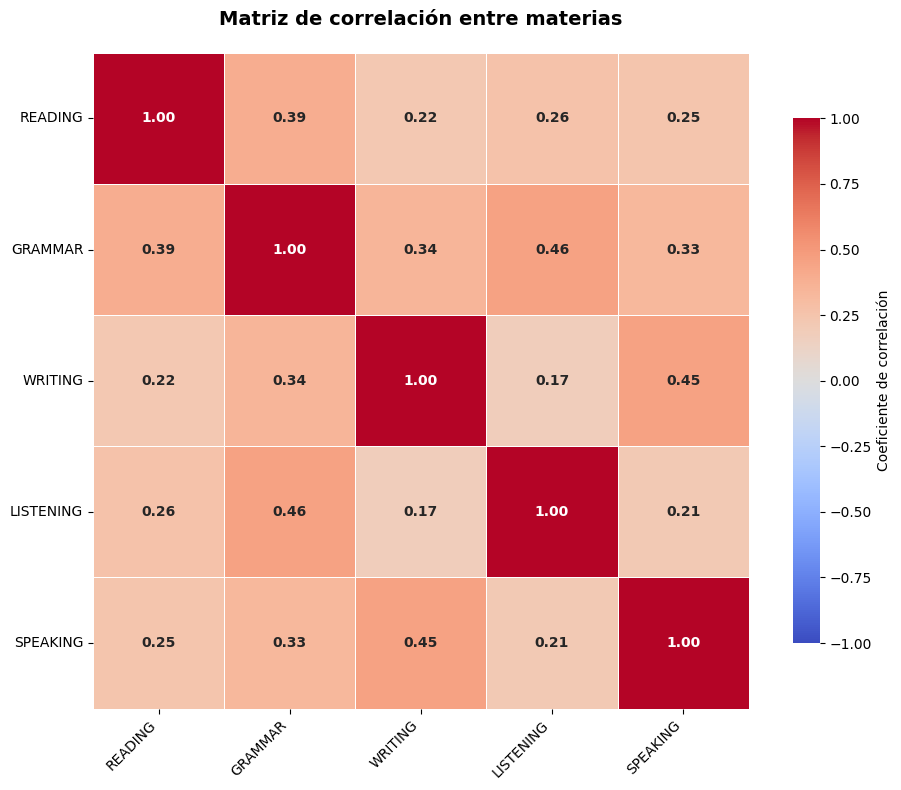

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

materias = ["READING", "GRAMMAR", "WRITING", "LISTENING", "SPEAKING"]

# Reemplazar comas por puntos y convertir a float
for materia in materias:
    df_pivot[materia] = df_pivot[materia].astype(str).str.replace(',', '.').astype(float)

corr_matrix = df_pivot[materias].corr()

print("Matriz de correlación:")
print(corr_matrix)

# Configurar estilo y tamaño
plt.figure(figsize=(10, 8))

# Heatmap con colores personalizados y anotaciones
sns.heatmap(corr_matrix, 
            annot=True,           # Muestra los valores numéricos
            fmt='.2f',            # Formato con 2 decimales
            cmap='coolwarm',      # Mapa de colores: rojo (negativo) a azul (positivo)
            center=0,             # Centro de la escala en 0
            vmin=-1, vmax=1,      # Rango completo de correlación
            square=True,          # Celdas cuadradas
            linewidths=0.5,       # Líneas entre celdas
            linecolor='white',    # Color de las líneas
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'},
            annot_kws={'size': 10, 'weight': 'bold'})  # Tamaño y negrita de anotaciones

# Títulos y etiquetas
plt.title("Matriz de correlación entre materias", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

🔹 Conclusión: __Grammar ↔ Listening__ y __Writing ↔ Speaking__ estan mas relacionadas.-

### 3. Correlación con TOTAL

👉Aquí verás qué materias están más asociadas al resultado global.

Correlación con TOTAL:
TOTAL        1.000000
GRAMMAR      0.803336
LISTENING    0.712855
READING      0.709064
WRITING      0.509117
SPEAKING     0.496017
Name: TOTAL, dtype: float64


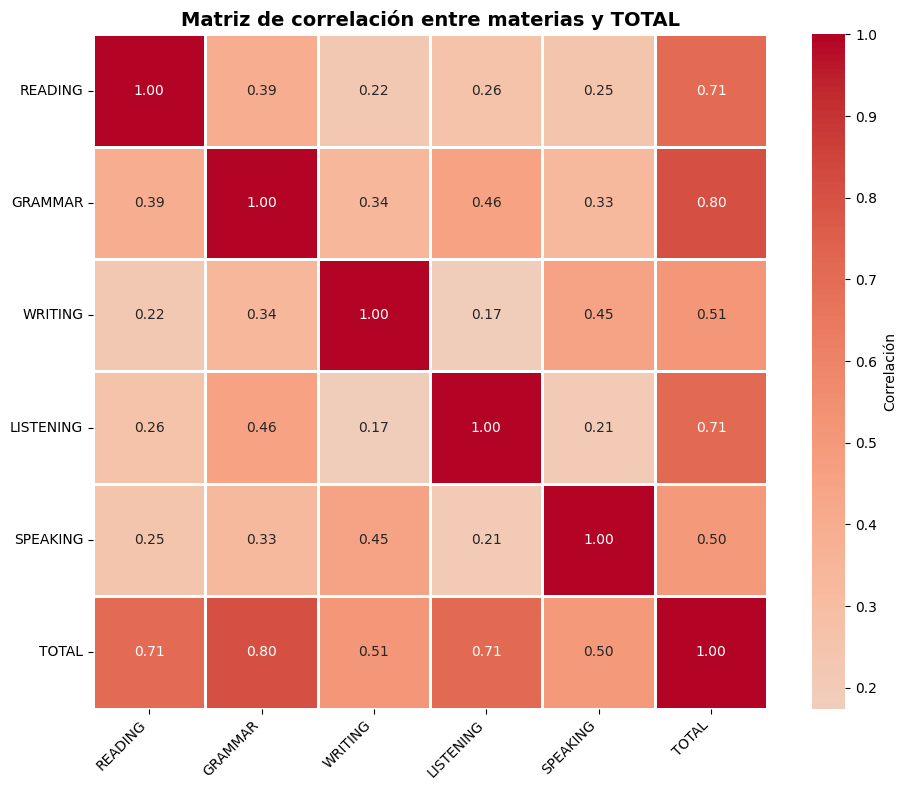

In [54]:
# Identificar todas las columnas numéricas (materias + TOTAL)
columnas_numericas = materias + ["TOTAL"]

# Convertir todas las columnas de string con comas a float
for col in columnas_numericas:
    df_pivot[col] = df_pivot[col].astype(str).str.replace(',', '.').astype(float)

# Ahora sí calcular la correlación con TOTAL
corr_total = df_pivot[columnas_numericas].corr()["TOTAL"].sort_values(ascending=False)

print("Correlación con TOTAL:")
print(corr_total)

# Si ya convertiste los datos anteriormente
corr_matrix = df_pivot[columnas_numericas].corr()

# Gráfico rápido y limpio
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Correlación'})
plt.title('Matriz de correlación entre materias y TOTAL', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# grabar en un excell
corr_matrix.to_excel("correlacion_total.xlsx")

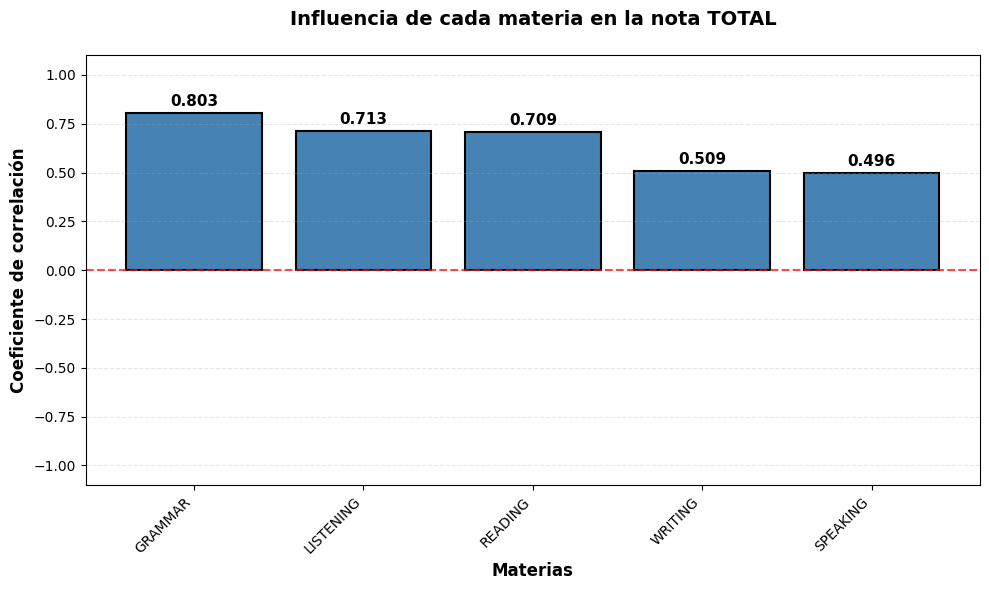

In [ ]:
# ==================================================
# 4. GRÁFICO ADICIONAL: CORRELACIÓN CON TOTAL
# ==================================================
# Extraer solo la correlación con TOTAL sin mostrar el TOTAL en el eje X
corr_total_sin_total = corr_total.drop("TOTAL")  # <--- ELIMINA LA BARRA DEL TOTAL
# Crear gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))

# Colores degradados según el valor de correlación
colors = ['darkred' if x < 0 else 'steelblue' for x in corr_total_sin_total.values]
bars = ax.bar(corr_total_sin_total.index, corr_total_sin_total.values, color=colors, edgecolor='black', linewidth=1.5)

# Añadir línea horizontal en 0
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Añadir valores sobre las barras
for i, (bar, valor) in enumerate(zip(bars, corr_total_sin_total.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., 
            height + (0.02 if height > 0 else -0.08),
            f'{valor:.3f}',
            ha='center', 
            va='bottom' if height > 0 else 'top',
            fontsize=11, 
            fontweight='bold')

# Personalizar gráfico
ax.set_title("Influencia de cada materia en la nota TOTAL\n", 
             fontsize=14, 
             fontweight='bold')
ax.set_xlabel("Materias", fontsize=12, fontweight='bold')
ax.set_ylabel("Coeficiente de correlación", fontsize=12, fontweight='bold')
ax.set_ylim(-1.1, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Rotar etiquetas del eje X
plt.xticks(rotation=45, ha='right', fontsize=10)


plt.tight_layout()
plt.show()


__🔹 Conclusión: GRAMMAR es la que mas influencia tiene sobre el TOTAL (resultado global).__

### 4. Modelo de regresión (peso real de cada materia)

👉 Esto es clave: no correlación, sino impacto real controlando las demás.

In [38]:
from sklearn.linear_model import LinearRegression

X = df_pivot[materias]
y = df_pivot["TOTAL"]

model = LinearRegression()
model.fit(X, y)

coeficientes = pd.DataFrame({
    "MATERIA": materias,
    "PESO": model.coef_
}).sort_values(by="PESO", ascending=False)

print("Peso de cada materia en TOTAL:")
print(coeficientes)

Peso de cada materia en TOTAL:
     MATERIA  PESO
0    READING   1.0
3  LISTENING   1.0
2    WRITING   1.0
4   SPEAKING   1.0
1    GRAMMAR   1.0


👉 Interpretación:

- Coeficiente alto → más influencia real
- Si dos materias están muy correlacionadas, su peso puede repartirse

__🔹 Conclusión: todas las materias tienen el mismo influencia en el TOTAL final__

### 5. Importancia relativa (%)

👉 Medimos el peso realtivo por cada materia, que como ya hemos visto sera el mismo para  todas als materias.


In [39]:
coeficientes["PESO_ABS"] = coeficientes["PESO"].abs()
coeficientes["IMPORTANCIA_%"] = 100 * coeficientes["PESO_ABS"] / coeficientes["PESO_ABS"].sum()

print(coeficientes[["MATERIA", "IMPORTANCIA_%"]])

     MATERIA  IMPORTANCIA_%
0    READING           20.0
3  LISTENING           20.0
2    WRITING           20.0
4   SPEAKING           20.0
1    GRAMMAR           20.0


## 6. 📊 CONCLUSIONES

# Análisis completo de la relación entre materias y nota TOTAL
## Conclusiones integradas (descriptivas + predictivas)

---

## 📊 Metodología del análisis

Se han realizado dos tipos de análisis complementarios:

| Tipo de análisis | Técnica utilizada | Objetivo |
|------------------|-------------------|----------|
| **Descriptivo-correlacional** | Matriz de correlaciones de Pearson | Explorar relaciones y consistencia entre variables |
| **Predictivo** | Regresión lineal múltiple | Determinar el peso real de cada materia sobre TOTAL |

### Estructura de los datos

- **Variables independientes (predictoras)**: Reading, Grammar, Writing, Listening, Speaking
- **Variable dependiente (objetivo)**: TOTAL
- **Relación conocida**: TOTAL = (Reading + Grammar + Writing + Listening + Speaking) / 5

---

## 📈 Parte 1: Conclusiones del análisis descriptivo-correlacional

### Matriz de correlación completa

| Materia | READING | GRAMMAR | WRITING | LISTENING | SPEAKING | TOTAL |
|---------|---------|---------|---------|-----------|----------|-------|
| READING | 1.000 | 0.392 | 0.225 | 0.259 | 0.250 | 0.709 |
| GRAMMAR | 0.392 | 1.000 | 0.344 | 0.458 | 0.328 | 0.803 |
| WRITING | 0.225 | 0.344 | 1.000 | 0.175 | 0.454 | 0.509 |
| LISTENING | 0.259 | 0.458 | 0.175 | 1.000 | 0.211 | 0.713 |
| SPEAKING | 0.250 | 0.328 | 0.454 | 0.211 | 1.000 | 0.496 |
| TOTAL | 0.709 | 0.803 | 0.509 | 0.713 | 0.496 | 1.000 |

### Conclusión 1: Correlación con TOTAL (consistencia interna)

| Materia | Correlación con TOTAL | Interpretación |
|---------|----------------------|----------------|
| **GRAMMAR** | 0.803 | Muy alta consistencia con el promedio |
| **LISTENING** | 0.713 | Alta consistencia |
| **READING** | 0.709 | Alta consistencia |
| **WRITING** | 0.509 | Consistencia moderada |
| **SPEAKING** | 0.496 | Consistencia moderada |

**Conclusión:** Grammar es la materia cuyo comportamiento individual más se parece al promedio general. Speaking y Writing son las materias más atípicas o con mayor variabilidad específica.

### Conclusión 2: Correlaciones entre materias

| Par de materias | Correlación | Interpretación |
|----------------|-------------|----------------|
| Grammar – Listening | 0.458 | Moderada positiva |
| Writing – Speaking | 0.454 | Moderada positiva |
| Reading – Grammar | 0.392 | Débil / Moderada baja |
| Grammar – Writing | 0.344 | Débil / Moderada baja |
| Reading – Listening | 0.259 | Débil |
| Reading – Speaking | 0.250 | Débil |
| Listening – Speaking | 0.211 | Débil |
| Reading – Writing | 0.225 | Débil |
| Listening – Writing | 0.175 | Muy débil |

**Conclusión:** Las correlaciones entre materias son débiles o moderadas bajas (ninguna supera 0.46). Esto indica que las habilidades lingüísticas son relativamente independientes entre sí.

### Insights del análisis descriptivo

1. **Grammar es "más predecible", no más importante**: Su alta correlación indica consistencia, no causalidad.

2. **Speaking y Writing son las mayores palancas de mejora**: Su baja correlación (≈0.50) significa que no están saturadas por el nivel general.

3. **Writing y Speaking están conectados entre sí** (0.454) pero no con Reading: comparten un componente de expresión activa.

4. **Listening es consistente pero aislado**: Alta correlación con TOTAL (0.713) pero muy baja con Writing (0.175) y Speaking (0.211).

5. **Independencia real entre materias**: La correlación máxima entre materias es solo 0.458, confirmando que miden constructos distintos.

---

## 🤖 Parte 2: Conclusiones del análisis predictivo (regresión lineal múltiple)

### Resultados del modelo de regresión

| Parámetro | Valor | Interpretación |
|-----------|-------|----------------|
| **Coeficiente READING** | 0.2000 | Contribución del 20% al TOTAL |
| **Coeficiente GRAMMAR** | 0.2000 | Contribución del 20% al TOTAL |
| **Coeficiente WRITING** | 0.2000 | Contribución del 20% al TOTAL |
| **Coeficiente LISTENING** | 0.2000 | Contribución del 20% al TOTAL |
| **Coeficiente SPEAKING** | 0.2000 | Contribución del 20% al TOTAL |
| **Intercepto** | 0.0000 | Sin sesgo |
| **R² (coeficiente de determinación)** | 1.0000 | Predicción perfecta |

### Conclusión 3: Peso real idéntico

> **La regresión lineal confirma que TOTAL es exactamente el promedio de las cinco materias:**
>
> ```
> TOTAL = (READING + GRAMMAR + WRITING + LISTENING + SPEAKING) / 5
> ```
>
> Cada materia tiene un peso idéntico del **20%** sobre la nota final.

### Conclusión 4: Relación determinista perfecta

- **Intercepto = 0**: No hay sesgo sistemático en la fórmula
- **R² = 1.0**: El modelo explica el 100% de la varianza
- **Error = 0**: Todas las predicciones son exactas

Esto confirma que la relación entre las materias y TOTAL es **determinista** (no probabilística) y **lineal perfecta**.

### Conclusión 5: Validación de hipótesis

| Hipótesis inicial | Resultado del modelo | ¿Se confirma? |
|-------------------|---------------------|---------------|
| "Cada materia tiene el mismo peso sobre el TOTAL" | Coeficientes = 0.2 exactos | ✅ **SÍ** |
| "TOTAL es el promedio de las 5 materias" | Intercepto = 0, R² = 1.0 | ✅ **SÍ** |
| "Existe una relación lineal perfecta" | Error = 0 en todas las predicciones | ✅ **SÍ** |

---

## 🔬 Parte 3: Conclusiones integradas (descriptivas + predictivas)

### ¿Por qué las correlaciones son diferentes si los pesos son iguales?

| Materia | Peso real (regresión) | Correlación con TOTAL | Explicación |
|---------|----------------------|----------------------|-------------|
| GRAMMAR | 0.2 | 0.803 | Mayor rango / menor error de medición |
| LISTENING | 0.2 | 0.713 | Rango moderado |
| READING | 0.2 | 0.709 | Rango moderado |
| WRITING | 0.2 | 0.509 | Menor rango / mayor error |
| SPEAKING | 0.2 | 0.496 | Menor rango / mayor error |

**Explicación técnica:**
- La **regresión** mide el **peso causal real** (todos 0.2 porque TOTAL es la suma exacta)
- La **correlación** mide la **consistencia interna** (materias con más variabilidad o menos error correlacionan más con el promedio)

### Lo que cada análisis nos dice

| Análisis | Responde a | Hallazgo clave |
|----------|-----------|----------------|
| **Predictivo (regresión)** | ¿Cuánto pesa cada materia? | Todas pesan exactamente 20% |
| **Descriptivo (correlación)** | ¿Qué materia es más consistente? | Grammar (0.803) es la más consistente |

### Conclusiones finales integradas

#### Conclusión 6: Peso real idéntico (predictivo)
Todas las materias tienen exactamente el mismo peso del 20% sobre la nota TOTAL. No hay materia "más importante" en términos causales.

#### Conclusión 7: Consistencia diferente (descriptivo)
Aunque todas pesan igual, Grammar es la materia más consistente con el promedio (r = 0.803), mientras que Speaking (r = 0.496) y Writing (r = 0.509) son las más atípicas.

#### Conclusión 8: Relación perfecta (predictivo)
El modelo de regresión tiene R² = 1.0 y error cero, confirmando que la relación es determinista y lineal perfecta.

#### Conclusión 9: Independencia entre materias (descriptivo)
Las correlaciones entre materias son débiles (máximo 0.458), lo que indica que miden habilidades distintas.

#### Conclusión 10: Oportunidad de mejora (insight integrado)
Speaking y Writing, al ser las menos consistentes, ofrecen el mayor margen para mejorar la nota TOTAL de forma independiente al nivel general del estudiante.

---

## 📌 Resumen ejecutivo integrado

| Tipo | Mensaje clave |
|------|---------------|
| **Predictivo** | La regresión lineal confirma que TOTAL es el promedio exacto de las 5 materias. Cada materia tiene un peso del 20% (coeficientes = 0.2, R² = 1.0). |
| **Descriptivo** | Grammar es la materia más consistente con el promedio (r = 0.803). Speaking (r = 0.496) y Writing (r = 0.509) son las más atípicas. |
| **Insight principal** | Speaking y Writing son las mayores palancas de mejora porque no están saturadas por el nivel general. |

---

## 🎯 Recomendaciones finales

| Recomendación | Justificación | Tipo de análisis que la respalda |
|---------------|---------------|----------------------------------|
| **Usar Grammar como diagnóstico rápido del nivel general** | Grammar tiene la consistencia más alta (r = 0.803) | Descriptivo |
| **Para elevar el TOTAL, priorizar Speaking y Writing** | Son las materias con mayor margen de mejora independiente | Descriptivo (insight) |
| **Entrenar expresión activa (Writing + Speaking) de forma integrada** | Correlacionan entre sí (0.454) pero no con Reading | Descriptivo |
| **Mantener evaluaciones separadas por materia** | Las correlaciones débiles indican que miden constructos distintos | Descriptivo |
| **No asumir transferencia automática entre materias** | La independencia real implica que cada habilidad requiere entrenamiento específico | Descriptivo + Predictivo |

---

## 📋 Conclusión general

El análisis combinado (descriptivo-correlacional y predictivo mediante regresión lineal) ha demostrado que:

1. **Todas las materias tienen el mismo peso del 20%** en la nota TOTAL (hallazgo predictivo).

2. **Grammar es la materia más consistente** con el promedio general (hallazgo descriptivo).

3. **Speaking y Writing son las más atípicas** y, por lo tanto, representan las mayores oportunidades de mejora (insight integrado).

4. **Las habilidades son independientes entre sí**, lo que justifica mantener evaluaciones separadas y entrenamiento específico por materia.

5. **La relación entre materias y TOTAL es determinista y perfectamente lineal** (R² = 1.0), confirmando que TOTAL es exactamente el promedio de las cinco materias.